<a href="https://colab.research.google.com/github/JPAmewu/My_Capstone_1_Imperial/blob/main/Week_4_Capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip -q week_4_data.zip

replace week_4_data/function_8_inputs.npy? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [ ]:
import numpy as np

for fn in range(1, 9):
    X = np.load(f"week_4_data/function_{fn}_inputs.npy")
    y = np.load(f"week_4_data/function_{fn}_outputs.npy")

    print(f"Function {fn}")
    print("Shape:", X.shape, y.shape)

Function 1
Shape: (13, 2) (13,)
Function 2
Shape: (13, 2) (13,)
Function 3
Shape: (18, 3) (18,)
Function 4
Shape: (33, 4) (33,)
Function 5
Shape: (23, 4) (23,)
Function 6
Shape: (23, 5) (23,)
Function 7
Shape: (33, 6) (33,)
Function 8
Shape: (43, 8) (43,)



========== Function 1 ==========
Input shape: (13, 2)
Output shape: (13,)
Best output: 64.0
Worst output: -0.0036060626443634764
Mean output: 14.768953379796587
Std dev: 26.964954780166938


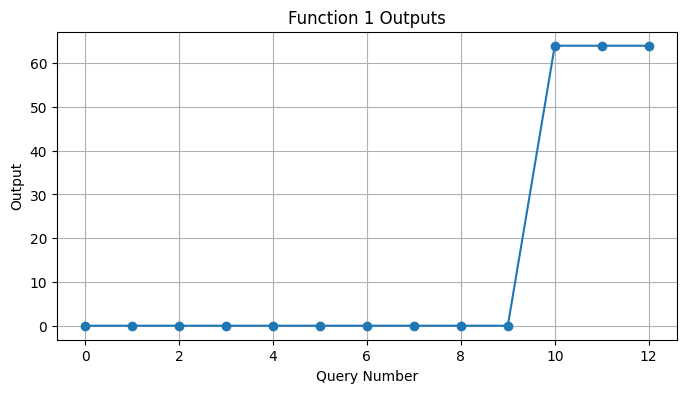


========== Function 2 ==========
Input shape: (13, 2)
Output shape: (13,)
Best output: 0.6112052157614438
Worst output: -0.06562362443733738
Mean output: 0.17744135870764796
Std dev: 0.22025942653368608


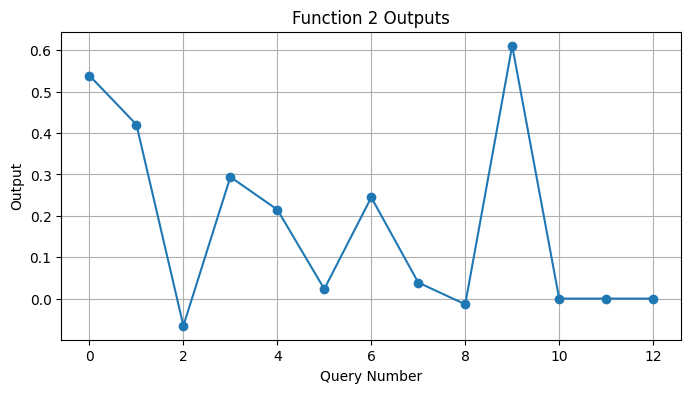


========== Function 3 ==========
Input shape: (18, 3)
Output shape: (18,)
Best output: 64.0
Worst output: -0.3989255131463011
Mean output: 10.577360854393232
Std dev: 23.89145421805894


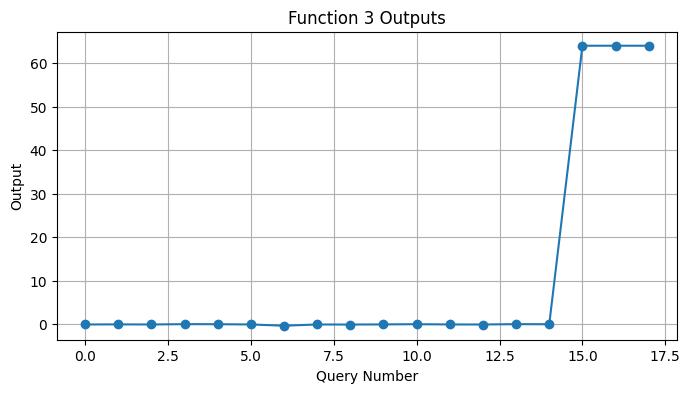


========== Function 4 ==========
Input shape: (33, 4)
Output shape: (33,)
Best output: -0.03182956281754251
Worst output: -32.625660215962455
Mean output: -15.674336643244022
Std dev: 8.32126517276037


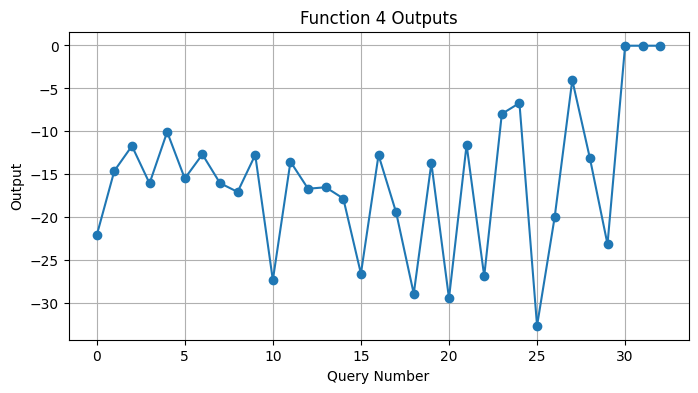


========== Function 5 ==========
Input shape: (23, 4)
Output shape: (23,)
Best output: 1088.8596181962705
Worst output: 0.1129397953712203
Mean output: 139.88858754696767
Std dev: 230.8792328895476


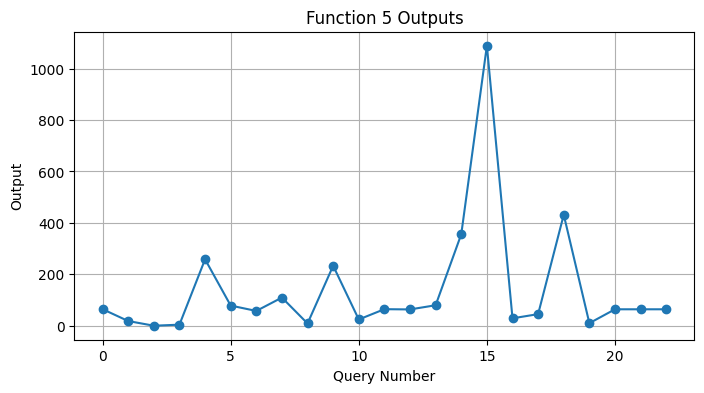


========== Function 6 ==========
Input shape: (23, 5)
Output shape: (23,)
Best output: -0.04090761844901528
Worst output: -2.5711696316081234
Mean output: -1.305674854314173
Std dev: 0.6443991943533699


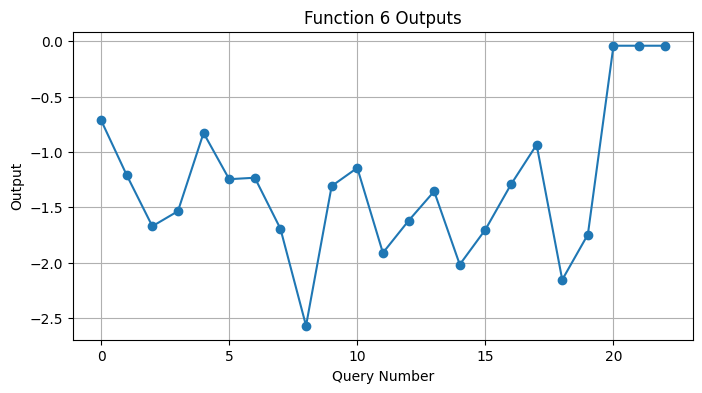


========== Function 7 ==========
Input shape: (33, 6)
Output shape: (33,)
Best output: 64.0
Worst output: 0.0027014650245082332
Mean output: 6.017824160021296
Std dev: 18.337836713162392


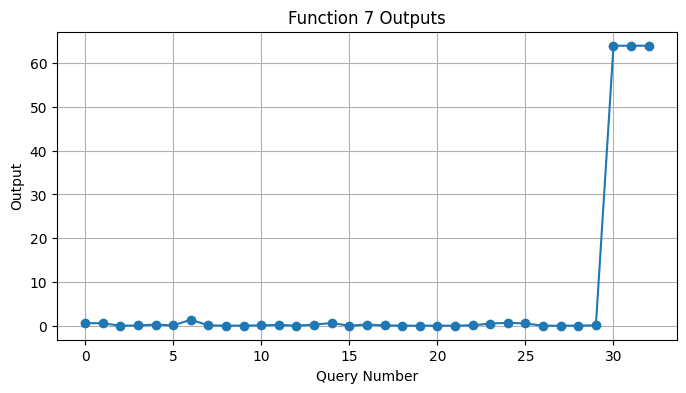


========== Function 8 ==========
Input shape: (43, 8)
Output shape: (43,)
Best output: 9.598482002566342
Worst output: -8.727516493155957
Mean output: 6.661126252258027
Std dev: 4.312174076980716


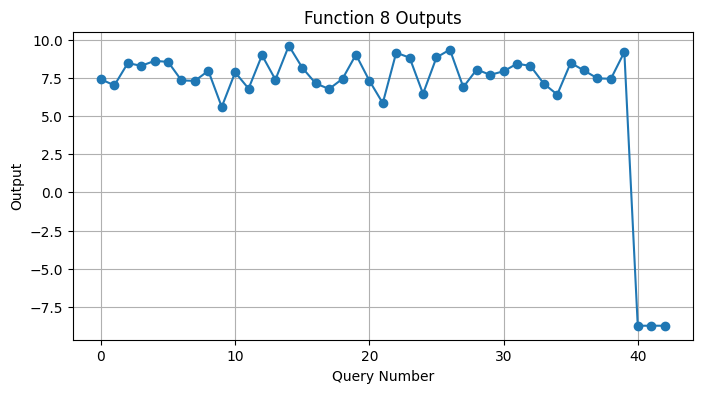

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

for fn in range(1, 9):
    X = np.load(f"week_4_data/function_{fn}_inputs.npy")
    y = np.load(f"week_4_data/function_{fn}_outputs.npy")

    print(f"\n========== Function {fn} ==========")
    print("Input shape:", X.shape)
    print("Output shape:", y.shape)
    print("Best output:", np.max(y))
    print("Worst output:", np.min(y))
    print("Mean output:", np.mean(y))
    print("Std dev:", np.std(y))

    # Plot outputs
    plt.figure(figsize=(8,4))
    plt.plot(y, marker='o')
    plt.title(f"Function {fn} Outputs")
    plt.xlabel("Query Number")
    plt.ylabel("Output")
    plt.grid(True)
    plt.show()

In [ ]:
import numpy as np

for fn in range(1, 9):
    X = np.load(f"week_4_data/function_{fn}_inputs.npy")
    y = np.load(f"week_4_data/function_{fn}_outputs.npy")

    best_idx = np.argmax(y)

    print(f"\n========== Function {fn} ==========")
    print("Best output:", y[best_idx])
    print("Best query point:", np.round(X[best_idx], 6))


========== Function 1 ==========
Best output: 64.0
Best query point: [0.37454  0.950714]

========== Function 2 ==========
Best output: 0.6112052157614438
Best query point: [0.702637 0.926564]

========== Function 3 ==========
Best output: 64.0
Best query point: [0.444444 0.666666 0.333333]

========== Function 4 ==========
Best output: -0.03182956281754251
Best query point: [0.555555 0.444444 0.222222 0.111111]

========== Function 5 ==========
Best output: 1088.8596181962705
Best query point: [0.224189 0.84648  0.879484 0.878516]

========== Function 6 ==========
Best output: -0.04090761844901528
Best query point: [0.728186 0.154693 0.732552 0.693997 0.564013]

========== Function 7 ==========
Best output: 64.0
Best query point: [0.045091 0.528666 0.329265 0.10535  0.434667 0.641164]

========== Function 8 ==========
Best output: 9.598482002566342
Best query point: [0.056447 0.065956 0.022929 0.038786 0.403935 0.801055 0.488307 0.893085]


In [ ]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
import numpy as np

week_4_queries = {}

# Same strategy as Week 3
kappa_values = {
    1: 5,
    2: 5,
    3: 5,
    4: 5,
    6: 5,
    7: 3,
    8: 2
}

for fn in [1, 2, 3, 4, 6, 7, 8]:

    # Load raw dataset
    X = np.load(f"week_4_data/function_{fn}_inputs.npy")
    y = np.load(f"week_4_data/function_{fn}_outputs.npy")

    # Fit GP
    gp = GaussianProcessRegressor(
        kernel=RBF(length_scale=1.0),
        normalize_y=True
    )
    gp.fit(X, y)

    # Random candidate search
    candidates = np.random.rand(5000, X.shape[1])

    # Predict mean and uncertainty
    mu, sigma = gp.predict(candidates, return_std=True)

    # UCB acquisition
    kappa = kappa_values[fn]
    ucb = mu + kappa * sigma

    # Best next point
    best_idx = np.argmax(ucb)
    next_query = candidates[best_idx]

    # Keep within submission bounds
    next_query = np.clip(next_query, 0, 1)

    # Round to 6 decimal places
    next_query = np.round(next_query, 6)

    week_4_queries[fn] = next_query

    print(f"Function {fn}: {'-'.join(map(str, next_query))}")

# Manual reasoning for Function 5
week_4_queries[5] = np.array([0.000000, 0.000000, 0.000000, 0.000000])

print(f"Function 5: {'-'.join(map(str, week_4_queries[5]))}")

Function 1: 0.872626-0.321598
Function 2: 0.197553-0.808683
Function 3: 0.650132-0.218327-0.110542
Function 4: 0.715715-0.504442-0.275065-0.552962
Function 6: 0.973181-0.022807-0.714484-0.145453-0.97479
Function 7: 0.045103-0.016167-0.773003-0.156031-0.147073-0.616114
Function 8: 0.356502-0.157574-0.172997-0.610561-0.106477-0.260297-0.411421-0.90474
Function 5: 0.0-0.0-0.0-0.0


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The opti

In [ ]:
# Exploration vs Exploitation Analysis

for fn in range(1,9):
    X = np.load(f"week_4_data/function_{fn}_inputs.npy")
    y = np.load(f"week_4_data/function_{fn}_outputs.npy")

    best_idx = np.argmax(y)
    best_query = X[best_idx]

    new_query = week_4_queries[fn]

    distance = np.linalg.norm(new_query - best_query)

    print(f"Function {fn}")
    print("Best query:", np.round(best_query,6))
    print("New query :", np.round(new_query,6))
    print("Distance  :", round(distance,6))
    print("-"*40)

Function 1
Best query: [0.37454  0.950714]
New query : [0.872626 0.321598]
Distance  : 0.802419
----------------------------------------
Function 2
Best query: [0.702637 0.926564]
New query : [0.197553 0.808683]
Distance  : 0.518657
----------------------------------------
Function 3
Best query: [0.444444 0.666666 0.333333]
New query : [0.650132 0.218327 0.110542]
Distance  : 0.54125
----------------------------------------
Function 4
Best query: [0.555555 0.444444 0.222222 0.111111]
New query : [0.715715 0.504442 0.275065 0.552962]
Distance  : 0.476734
----------------------------------------
Function 5
Best query: [0.224189 0.84648  0.879484 0.878516]
New query : [0. 0. 0. 0.]
Distance  : 1.52055
----------------------------------------
Function 6
Best query: [0.728186 0.154693 0.732552 0.693997 0.564013]
New query : [0.973181 0.022807 0.714484 0.145453 0.97479 ]
Distance  : 0.739852
----------------------------------------
Function 7
Best query: [0.045091 0.528666 0.329265 0.10535  

In [ ]:
# Dimensional Sensitivity Analysis

for fn in range(1,9):
    X = np.load(f"week_4_data/function_{fn}_inputs.npy")

    print(f"\nFunction {fn}")
    print("Mean per dimension:", np.round(np.mean(X, axis=0),6))
    print("Std per dimension :", np.round(np.std(X, axis=0),6))


Function 1
Mean per dimension: [0.508599 0.63441 ]
Std per dimension : [0.227793 0.301122]

Function 2
Mean per dimension: [0.500673 0.594726]
Std per dimension : [0.209095 0.33018 ]

Function 3
Mean per dimension: [0.414933 0.542508 0.391212]
Std per dimension : [0.242921 0.212814 0.251923]

Function 4
Mean per dimension: [0.544025 0.474157 0.443559 0.441098]
Std per dimension : [0.275637 0.289736 0.255043 0.293308]

Function 5
Mean per dimension: [0.429579 0.543938 0.530319 0.544779]
Std per dimension : [0.221297 0.274912 0.261923 0.308716]

Function 6
Mean per dimension: [0.571299 0.509369 0.501826 0.555245 0.442041]
Std per dimension : [0.282031 0.292093 0.300176 0.260332 0.274221]

Function 7
Mean per dimension: [0.46851  0.407881 0.384123 0.475777 0.464243 0.498927]
Std per dimension : [0.314823 0.239838 0.294904 0.315036 0.29519  0.256467]

Function 8
Mean per dimension: [0.516404 0.457376 0.48513  0.405899 0.496395 0.444121 0.54637  0.495967]
Std per dimension : [0.303249 0.29